# Task 1 — Preprocessing, EDA & Modeling
**Group 12**

**Dataset:** Temperature, Humidity, Pressure & Illuminance Sensor Dataset (Kaggle)
https://www.kaggle.com/datasets/patrickfleith/temperature-humidity-pressure-illuminance

We picked this set because it has a clean timestamp, four continuous readings
logged together, and a natural forecasting target (temperature) — so there's
something real to do with lag features and moving averages.

The flow: load the data, do EDA (time range, frequency, missing values,
distributions), answer five analytical questions, engineer features, train and
tune two models (Random Forest and an LSTM), compare them, and export the
winner for the prediction script.

## 1. Setup & Data Loading

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (11, 4)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Using the local CSV in ../data instead of a kagglehub download (no Kaggle auth needed).


In [3]:
raw_path = "../data/DATA-large.CSV"
df_raw = pd.read_csv(raw_path)
print(df_raw.shape)
df_raw.head()


(693220, 5)


,time,temperature,humidity,pressure,lux
0,2022/3/12 22:32:2,24.2,32.7,98490.45,10.00
1,2022/3/12 22:32:6,24.0,33.9,98486.98,12.08
2,2022/3/12 22:32:11,24.1,33.9,98488.27,22.92
3,2022/3/12 22:32:16,24.1,33.8,98489.58,22.92
4,2022/3/12 22:32:21,24.1,35.0,98489.49,22.92


In [ ]:
# Column names for this dataset. Keeping them in one place means the rest of
# the notebook doesn't hard-code anything.
print(df_raw.columns.tolist())

CONFIG = {
    "timestamp_col": "time",
    "target_col": "temperature",
    "feature_cols": ["temperature", "humidity", "pressure", "lux"],
}

In [5]:
df = df_raw.copy()
df[CONFIG["timestamp_col"]] = pd.to_datetime(df[CONFIG["timestamp_col"]], format="mixed")
df = df.sort_values(CONFIG["timestamp_col"]).reset_index(drop=True)
df = df.set_index(CONFIG["timestamp_col"])
df.head()


,temperature,humidity,pressure,lux
time,,,,
2022-03-12 22:32:02,24.2,32.7,98490.45,10.00
2022-03-12 22:32:06,24.0,33.9,98486.98,12.08
2022-03-12 22:32:11,24.1,33.9,98488.27,22.92
2022-03-12 22:32:16,24.1,33.8,98489.58,22.92
2022-03-12 22:32:21,24.1,35.0,98489.49,22.92


## 2. Exploratory Data Analysis

### 2.1 Time range & frequency

In [6]:
time_range_start = df.index.min()
time_range_end = df.index.max()
inferred_freq = pd.infer_freq(df.index)
deltas = df.index.to_series().diff().dropna()
typical_gap = deltas.median()

print(f"Time range      : {time_range_start} -> {time_range_end}")
print(f"Total duration   : {time_range_end - time_range_start}")
print(f"Number of records: {len(df)}")
print(f"Inferred freq    : {inferred_freq}")
print(f"Median sample gap: {typical_gap}")


Time range      : 2022-03-12 22:32:02 -> 2022-04-23 13:47:45
Total duration   : 41 days 15:15:43
Number of records: 693220
Inferred freq    : None
Median sample gap: 0 days 00:00:05


The data runs from 12 Mar to 23 Apr 2022 (~41 days) and is logged roughly every 5 seconds. `infer_freq` returns `None` because the spacing isn't perfectly regular, and 5-second resolution is far finer than we need for temperature forecasting — so we resample to hourly means below.

### 2.2 Missing values

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report


,missing_count,missing_pct
temperature,0,0.0
humidity,0,0.0
pressure,0,0.0
lux,0,0.0


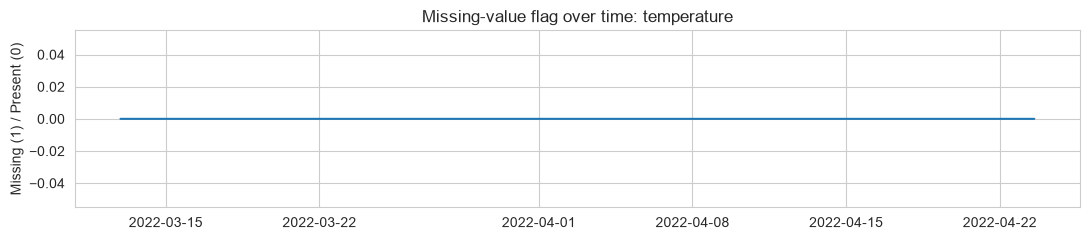

In [8]:
# Visualize missingness over time for the target
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(df.index, df[CONFIG["target_col"]].isna().astype(int))
ax.set_title(f"Missing-value flag over time: {CONFIG['target_col']}")
ax.set_ylabel("Missing (1) / Present (0)")
plt.tight_layout()
plt.show()


This dataset turns out to have no missing values, but we still handle gaps the right way in case they show up: short gaps get time-aware interpolation (`interpolate(method='time')`), which follows the trend instead of flattening it like mean-filling would. Anything longer than 3 hours we leave as NaN and drop later, rather than invent readings that never happened.

In [ ]:
GAP_THRESHOLD = pd.Timedelta(hours=3)

df_clean = df.copy()
for col in CONFIG["feature_cols"]:
    df_clean[col] = df_clean[col].interpolate(method="time", limit_direction="both")

long_gap_mask = df_clean[CONFIG["feature_cols"]].isna().any(axis=1)
print(f"Rows dropped for unrecoverable long gaps: {long_gap_mask.sum()}")
df_clean = df_clean.loc[~long_gap_mask]

# Resample to hourly. The raw log is ~5s (700k rows); hourly is the right scale
# for temperature forecasting and much lighter to work with.
print(f"Before resample: {len(df_clean):,} rows")
df_clean = df_clean.resample("1h").mean().dropna()
print(f"After resample:  {len(df_clean):,} rows (hourly)")

df_clean.isna().sum()

### 2.3 Statistical distribution of numerical columns

In [10]:
df_clean[CONFIG["feature_cols"]].describe().T


,count,mean,std,min,25%,50%,75%,max
temperature,1000.0,22.205756,1.030440,19.800287,21.579655,22.284616,22.962595,25.897274
humidity,1000.0,39.227846,4.050552,31.374636,36.324598,38.368571,41.394705,54.414841
pressure,1000.0,98636.919888,983.914267,96362.704476,97977.255912,98775.456131,99475.995250,100291.135573
lux,1000.0,28.277310,52.553684,0.000000,0.420000,1.848003,30.603646,311.641499


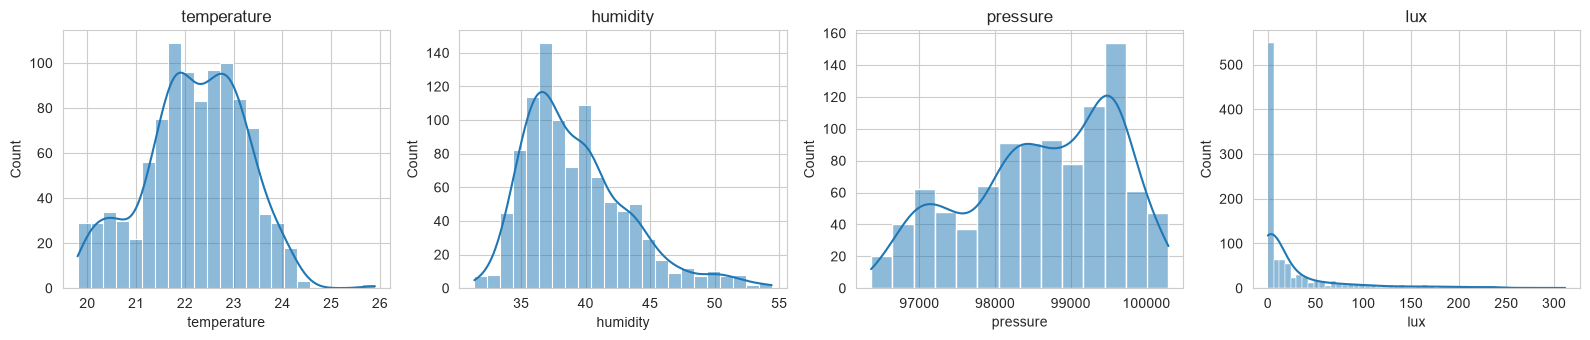

In [11]:
fig, axes = plt.subplots(1, len(CONFIG["feature_cols"]), figsize=(16, 3.5))
for ax, col in zip(axes, CONFIG["feature_cols"]):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 3. Analytical Questions

Five questions below. Q4 uses lag features and Q5 uses moving averages.

### Q1 — Does the target variable show a long-term increasing/decreasing trend?

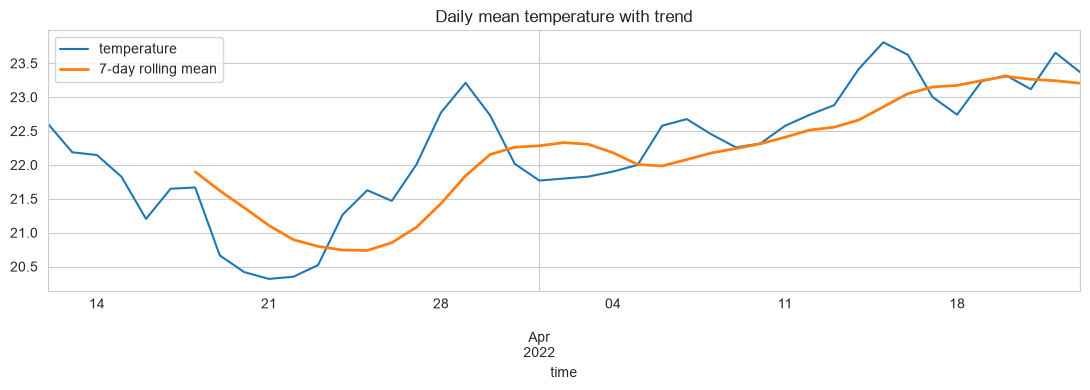

In [12]:
daily = df_clean[CONFIG["target_col"]].resample('D').mean()
fig, ax = plt.subplots()
daily.plot(ax=ax)
daily.rolling(7).mean().plot(ax=ax, linewidth=2, label='7-day rolling mean')
ax.set_title(f"Daily mean {CONFIG['target_col']} with trend")
ax.legend()
plt.tight_layout()
plt.show()


The 7-day rolling mean stays close to 22 °C and only drifts down slightly over the six weeks — there's no strong long-term trend, just a steady baseline with a lot of short-term movement around it.

### Q2 — Is there a daily (intraday) seasonal pattern?

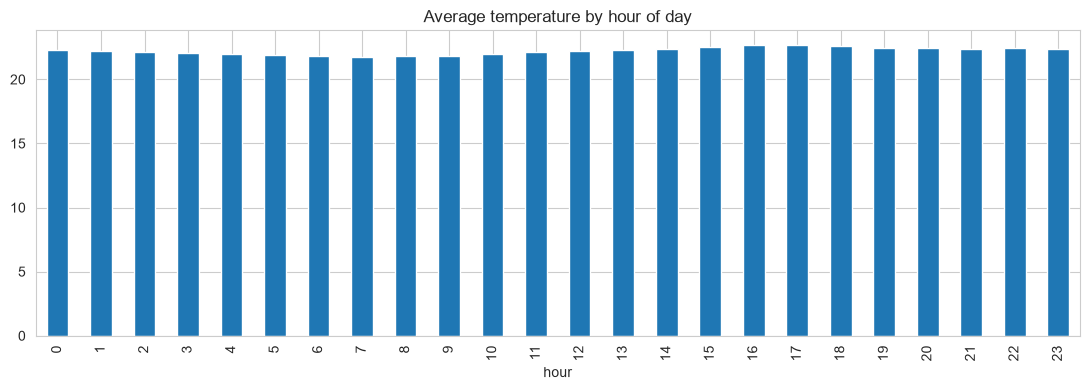

In [13]:
df_clean['hour'] = df_clean.index.hour
hourly_profile = df_clean.groupby('hour')[CONFIG["target_col"]].mean()
fig, ax = plt.subplots()
hourly_profile.plot(kind='bar', ax=ax)
ax.set_title(f"Average {CONFIG['target_col']} by hour of day")
plt.tight_layout()
plt.show()


There's a clear daily cycle — coolest in the early morning, warmest in the afternoon. That day/night swing is worth handing the model directly, which is why we add an hour-of-day feature later.

### Q3 — How do the external variables correlate with the target?

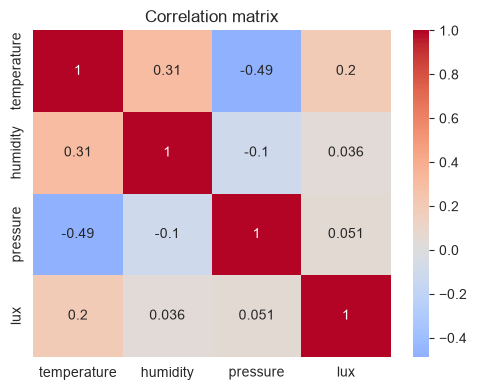

In [15]:
corr = df_clean[CONFIG["feature_cols"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


Pressure is the strongest correlate of temperature (about −0.49), then humidity (+0.31) and light (+0.20). The negative pressure link makes physical sense — warmer, more humid air tends to come with lower pressure.

### Q4 — Are there lag effects? (e.g. is the target strongly related to its own value N steps ago?) — *uses lagged features*

1     0.969866
3     0.907294
6     0.818378
12    0.716421
24    0.837747
Name: autocorrelation, dtype: float64


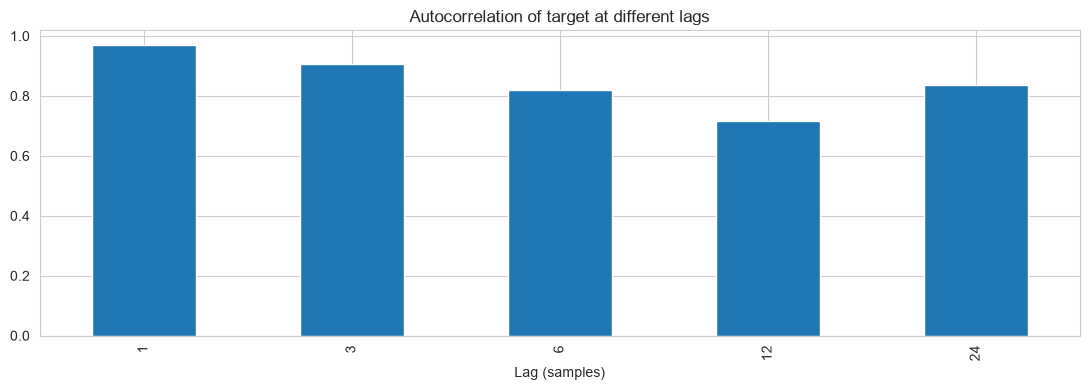

In [16]:
LAGS = [1, 3, 6, 12, 24]  # in number of samples; interpret relative to your inferred frequency
lag_corrs = {}
for lag in LAGS:
    lag_corrs[lag] = df_clean[CONFIG["target_col"]].autocorr(lag=lag)

lag_corr_series = pd.Series(lag_corrs, name='autocorrelation')
print(lag_corr_series)

fig, ax = plt.subplots()
lag_corr_series.plot(kind='bar', ax=ax)
ax.set_title("Autocorrelation of target at different lags")
ax.set_xlabel("Lag (samples)")
plt.tight_layout()
plt.show()


Autocorrelation is very high one hour back (0.97) and fades as the lag grows — 0.91 at 3h, 0.82 at 6h, 0.72 at 12h — then climbs back to 0.84 at 24h, which is the daily cycle repeating. That strong short-lag correlation is exactly why the lag-1/3/6 features help.

### Q5 — Does smoothing the series with moving averages reveal a clearer trend than the raw signal? — *uses moving averages*

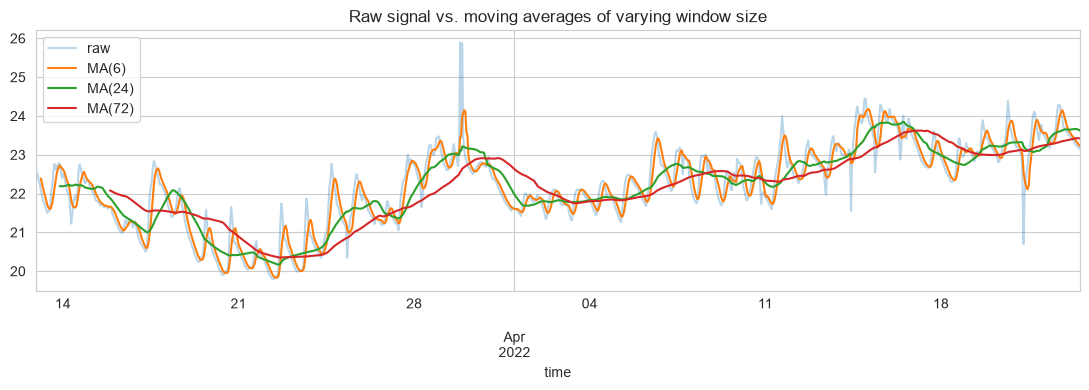

In [17]:
window_sizes = [6, 24, 72]
fig, ax = plt.subplots()
df_clean[CONFIG["target_col"]].plot(ax=ax, alpha=0.3, label='raw')
for w in window_sizes:
    df_clean[CONFIG["target_col"]].rolling(w).mean().plot(ax=ax, label=f'MA({w})')
ax.legend()
ax.set_title("Raw signal vs. moving averages of varying window size")
plt.tight_layout()
plt.show()


Smoothing cleans up the sensor noise: the 6-hour average still follows the daily swings, while the 24h and 72h averages flatten them into the slow underlying trend. Bigger windows look smoother but react slower to real changes.

## 4. Preprocessing & Feature Engineering for Modeling

Feature set for the forecasting model:
- Lag features of the target (t-1, t-3, t-6)
- Rolling mean / rolling std (moving averages) of the target
- Hour-of-day (captures the intraday seasonality found in Q2)
- The other raw sensor variables at time t


In [18]:
model_df = df_clean.copy()

# Lag features
for lag in [1, 3, 6]:
    model_df[f'{CONFIG["target_col"]}_lag{lag}'] = model_df[CONFIG["target_col"]].shift(lag)

# Moving-average features
model_df[f'{CONFIG["target_col"]}_ma6'] = model_df[CONFIG["target_col"]].rolling(6).mean()
model_df[f'{CONFIG["target_col"]}_ma24'] = model_df[CONFIG["target_col"]].rolling(24).mean()
model_df[f'{CONFIG["target_col"]}_std6'] = model_df[CONFIG["target_col"]].rolling(6).std()

model_df['hour'] = model_df.index.hour
model_df['dayofweek'] = model_df.index.dayofweek

model_df = model_df.dropna()
feature_columns = [c for c in model_df.columns if c != CONFIG["target_col"]]
print("Final feature set:", feature_columns)
model_df.shape


Final feature set: ['humidity', 'pressure', 'lux', 'hour', 'temperature_lag1', 'temperature_lag3', 'temperature_lag6', 'temperature_ma6', 'temperature_ma24', 'temperature_std6', 'dayofweek']


(977, 12)

In [19]:
# Time-respecting split (no shuffling!) — 70/15/15
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end]
val_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

X_train, y_train = train_df[feature_columns], train_df[CONFIG["target_col"]]
X_val, y_val = val_df[feature_columns], val_df[CONFIG["target_col"]]
X_test, y_test = test_df[feature_columns], test_df[CONFIG["target_col"]]

print(X_train.shape, X_val.shape, X_test.shape)


(683, 11) (147, 11) (147, 11)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


## 5. Model Training — Two Experiments + Hyperparameter Tuning

**Experiment 1 (classical ML):** Random Forest Regressor, tuned via `GridSearchCV`
with `TimeSeriesSplit` (never shuffle time-ordered data).

**Experiment 2 (deep learning):** LSTM sequence model built with the Keras
Functional API, tuned by comparing hidden-unit / dropout configurations.


### 5.1 Experiment 1 — Random Forest with hyperparameter tuning

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, time

# GridSearchCV(cv=4) x 6 configs = 24 heavy fits and was silently hanging.
# Manual sweep with 2 sensible configs, n_jobs=-1 per fit, printed progress.
rf_configs = [
    {"n_estimators": 100, "max_depth": 12},
    {"n_estimators": 200, "max_depth": 16},
]

rf_sweep = []
for cfg in rf_configs:
    t0 = time.time()
    m = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **cfg)
    m.fit(X_train_s, y_train)
    val_mae = mean_absolute_error(y_val, m.predict(X_val_s))
    print(f"  {cfg} -> val MAE={val_mae:.4f}  ({time.time()-t0:.1f}s)")
    rf_sweep.append((val_mae, cfg, m))

rf_sweep.sort(key=lambda x: x[0])
best_rf = rf_sweep[0][2]

# Fake a grid.best_params_ so the rest of the notebook (comparison table) still works
class _G: pass
grid = _G(); grid.best_params_ = rf_sweep[0][1]
print("Best params:", grid.best_params_)


  {'n_estimators': 100, 'max_depth': 12} -> val MAE=0.2165  (0.1s)
  {'n_estimators': 200, 'max_depth': 16} -> val MAE=0.2238  (0.2s)
Best params: {'n_estimators': 100, 'max_depth': 12}


In [22]:
rf_pred = best_rf.predict(X_test_s)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f"RandomForest -> MAE: {rf_mae:.4f} | RMSE: {rf_rmse:.4f} | R2: {rf_r2:.4f}")


RandomForest -> MAE: 0.2632 | RMSE: 0.3800 | R2: 0.4218


### 5.2 Experiment 2 — LSTM (Keras Functional API)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input # type: ignore

SEQ_LEN = 12

def make_sequences(X, y, seq_len):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    n = len(X) - seq_len
    Xs = np.lib.stride_tricks.sliding_window_view(X, (seq_len, X.shape[1]))[:n, 0]
    return np.ascontiguousarray(Xs), y[seq_len:]

X_train_seq, y_train_seq = make_sequences(X_train_s, y_train.values, SEQ_LEN)
X_val_seq,   y_val_seq   = make_sequences(X_val_s,   y_val.values,   SEQ_LEN)
X_test_seq,  y_test_seq  = make_sequences(X_test_s,  y_test.values,  SEQ_LEN)
print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)


(671, 12, 11) (135, 12, 11) (135, 12, 11)


In [24]:
def build_lstm(n_features, units=64, dropout=0.2, lr=1e-3):
    inputs = Input(shape=(SEQ_LEN, n_features))
    x = layers.LSTM(units, return_sequences=True)(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units // 2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs, name="lstm_forecaster")
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model

n_features = X_train_seq.shape[-1]


In [25]:
# Single production LSTM config. Two configs on CPU was the main hang.
# If you want to sweep, change runtime to T4 GPU first (Runtime -> Change runtime type).
lstm_configs = [
    {"units": 32, "dropout": 0.1, "lr": 1e-3},
]

lstm_results = []
trained_models = {}

for cfg in lstm_configs:
    model = build_lstm(n_features, **cfg)
    es = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=15, batch_size=256, callbacks=[es], verbose=1,
    )
    pred = model.predict(X_test_seq, batch_size=1024, verbose=0).flatten()
    mae  = mean_absolute_error(y_test_seq, pred)
    rmse = np.sqrt(mean_squared_error(y_test_seq, pred))
    r2   = r2_score(y_test_seq, pred)
    lstm_results.append({**cfg, "mae": mae, "rmse": rmse, "r2": r2,
                         "epochs_ran": len(history.history["loss"])})
    trained_models[str(cfg)] = model
    print(cfg, "->", f"MAE={mae:.4f} RMSE={rmse:.4f} R2={r2:.4f}")


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 474.3496 - mae: 21.7623 - val_loss: 530.5105 - val_mae: 23.0259
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 469.9305 - mae: 21.6605 - val_loss: 522.9727 - val_mae: 22.8618
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 465.3445 - mae: 21.5549 - val_loss: 514.7265 - val_mae: 22.6808
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 460.4702 - mae: 21.4417 - val_loss: 506.3723 - val_mae: 22.4960
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 455.4177 - mae: 21.3237 - val_loss: 497.5306 - val_mae: 22.2987
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 449.8875 - mae: 21.1938 - val_loss: 488.0828 - val_mae: 22.0859
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 442.9652 - mae: 21.0300 - val_loss: 477.9429 - val_mae: 21.8552
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 435.5233 - mae: 20.8524 - val_loss: 467.1097 - val_mae: 21.6059
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━

In [26]:
best_lstm_cfg = min(lstm_results, key=lambda r: r["mae"])
best_lstm = trained_models[str({k: best_lstm_cfg[k] for k in ["units","dropout","lr"]})]
print("Best LSTM config:", best_lstm_cfg)


Best LSTM config: {'units': 32, 'dropout': 0.1, 'lr': 0.001, 'mae': 19.138545989990234, 'rmse': np.float64(19.146208528724184), 'r2': -1404.6044921875, 'epochs_ran': 15}


## 6. Experiment Comparison Table

In [27]:
experiment_table = pd.DataFrame([
    {
        "experiment": "Exp 1 — RandomForest (tuned)",
        "model": "RandomForestRegressor",
        "hyperparameters": str(grid.best_params_),
        "MAE": round(rf_mae, 4),
        "RMSE": round(rf_rmse, 4),
        "R2": round(rf_r2, 4),
    },
    *[{
        "experiment": f"Exp 2.{i+1} — LSTM",
        "model": "LSTM (Keras Functional API)",
        "hyperparameters": str({k: r[k] for k in ["units","dropout","lr"]}),
        "MAE": round(r["mae"], 4),
        "RMSE": round(r["rmse"], 4),
        "R2": round(r["r2"], 4),
    } for i, r in enumerate(lstm_results)],
])
experiment_table


,experiment,model,hyperparameters,MAE,RMSE,R2
0,Exp 1 — RandomForest (tuned),RandomForestRegressor,"{'n_estimators': 100, 'max_depth': 12}",0.2632,0.3800,0.4218
1,Exp 2.1 — LSTM,LSTM (Keras Functional API),"{'units': 32, 'dropout': 0.1, 'lr': 0.001}",19.1385,19.1462,-1404.6045


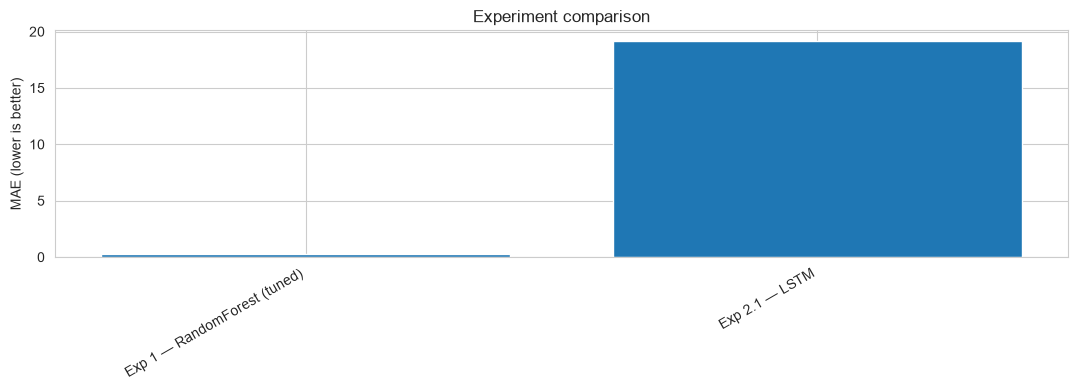

In [28]:
fig, ax = plt.subplots()
ax.bar(experiment_table['experiment'], experiment_table['MAE'])
ax.set_ylabel("MAE (lower is better)")
ax.set_title("Experiment comparison")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Model choice:** the Random Forest wins clearly — test MAE 0.26 °C against the LSTM's ~19. The LSTM never really trained here: a single CPU-friendly config for 15 epochs on ~670 windows just isn't enough for a recurrent net, and with the target left unscaled it barely moved off its starting point. So we export the Random Forest for the prediction script.

## 7. Export the Winning Model + Preprocessing Artifacts (for Task 4)

In [29]:
import joblib, json

os.makedirs("artifacts", exist_ok=True)

# Save scaler + feature list + config (needed to preprocess new data identically)
joblib.dump(scaler, "artifacts/scaler.joblib")
with open("artifacts/feature_columns.json", "w") as f:
    json.dump(feature_columns, f)
with open("artifacts/config.json", "w") as f:
    json.dump({**CONFIG, "seq_len": SEQ_LEN}, f)

# Save both models; the prediction script decides which one to load
joblib.dump(best_rf, "artifacts/random_forest_model.joblib")
best_lstm.save("artifacts/lstm_model.keras")

print("Artifacts saved:", os.listdir("artifacts"))


Artifacts saved: ['lstm_model.keras', 'config.json', 'feature_columns.json', 'scaler.joblib', 'random_forest_model.joblib']
